# Product Review Sentiment Analysis


## Dataset Download


In [17]:
import kagglehub

path = kagglehub.dataset_download("bittlingmayer/amazonreviews")

print(path)

Using Colab cache for faster access to the 'amazonreviews' dataset.
/kaggle/input/amazonreviews


## Data Preparation


In [18]:
import bz2
import pandas as pd

train_file = f"{path}/train.ft.txt.bz2"

reviews = []
labels = []

with bz2.open(train_file, mode='rt', encoding='utf-8') as f:

    for i, line in enumerate(f):

        if i >= 50000:  # first 50k reviews
            break

        if line.startswith('__label__1'):
            labels.append(0)  # Negative
        else:
            labels.append(1)  # Positive

        review = line.split(' ', 1)[1]
        reviews.append(review)

df = pd.DataFrame({
    "Review": reviews,
    "Sentiment": labels
})

print(df.head())
print(df.shape)

                                              Review  Sentiment
0  Stuning even for the non-gamer: This sound tra...          1
1  The best soundtrack ever to anything.: I'm rea...          1
2  Amazing!: This soundtrack is my favorite music...          1
3  Excellent Soundtrack: I truly like this soundt...          1
4  Remember, Pull Your Jaw Off The Floor After He...          1
(50000, 2)


## Feature Extraction using TF-IDF


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)

X = vectorizer.fit_transform(df['Review'])
y = df['Sentiment']

## Train-Test Split


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model Training


In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


## Model Evaluation


In [22]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8811


In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4955
           1       0.87      0.90      0.88      5045

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



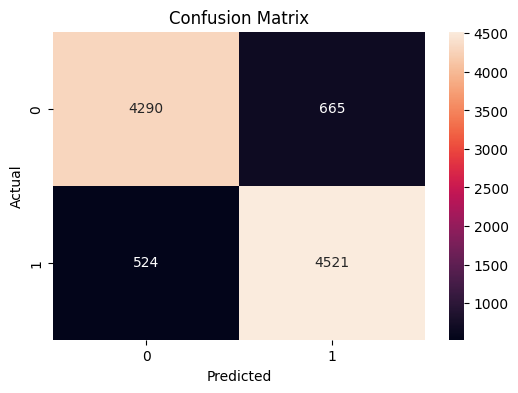

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Sentiment Prediction


In [25]:
def predict_sentiment(review):
    review_vector = vectorizer.transform([review])
    prediction = model.predict(review_vector)

    return "Positive" if prediction[0] == 1 else "Negative"


print(predict_sentiment("This product is amazing and worth every penny"))
print(predict_sentiment("Worst product ever, complete waste of money"))

Positive
Negative
